In [15]:
%pip install scikit-learn

# AQI Forecasting — LSTM Model
**Dataset:** AnandVihar_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** Stacked LSTM (Long Short-Term Memory) Neural Network

LSTMs are a type of recurrent neural network designed to learn long-range temporal dependencies.
They maintain a *cell state* that can carry information across many time steps, making them
well-suited for complex, non-linear time-series.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f'TensorFlow version: {tf.__version__}')
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


## 1. Load & Preprocess Data

In [17]:
df = pd.read_csv('D:/AQI_Project/Data/Final/AnandVihar_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

daily = df.resample('D').mean().dropna(subset=['AQI'])
print(f'Daily records: {len(daily)}')

Daily records: 1826


## 2. Multivariate Setup & Normalization

In [18]:
# Use AQI + pollutant sub-indices as features
feature_cols = ['AQI', 'PM25', 'PM10', 'NO2', 'SO2', 'O3']
daily[feature_cols] = daily[feature_cols].ffill().bfill()

# Scale to [0, 1]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

data_scaled = scaler_X.fit_transform(daily[feature_cols])
aqi_scaled  = scaler_y.fit_transform(daily[['AQI']])

print(f'Feature matrix shape: {data_scaled.shape}')

Feature matrix shape: (1826, 6)


## 3. Create Sequence Windows

In [19]:
SEQ_LEN = 30  # Use 30 days of history to predict next day

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(data_scaled, aqi_scaled.flatten(), SEQ_LEN)
print(f'Sequence shape: X={X_seq.shape}, y={y_seq.shape}')
print(f'Input shape per sample: (timesteps={SEQ_LEN}, features={len(feature_cols)})')

Sequence shape: X=(1796, 30, 6), y=(1796,)
Input shape per sample: (timesteps=30, features=6)


## 4. Train/Test Split

In [20]:
# Align with daily index (offset by SEQ_LEN)
dates = daily.index[SEQ_LEN:]
split_idx = np.searchsorted(dates, pd.Timestamp('2025-07-01'))

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
dates_test = dates[split_idx:]

# Further split train into train+val
val_idx = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_idx], X_train[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'Train={len(X_tr)}, Val={len(X_val)}, Test={len(X_test)}')

Train=1370, Val=242, Test=184


## 5. Build Stacked LSTM Model

In [21]:
def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber'  # Robust to outliers vs MSE
    )
    return model

model = build_lstm(SEQ_LEN, len(feature_cols))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,257 (516.63 KB)

 Trainable params: 131,873 (515.13 KB)

 Non-trainable params: 384 (1.50 KB)

## 6. Train Model

In [22]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1, min_lr=1e-5)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0318 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0200 - val_loss: 0.0240 - learning_rate: 0.0010
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0175 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0157 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0155 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0148 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0136 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0141 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0124 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 10/1

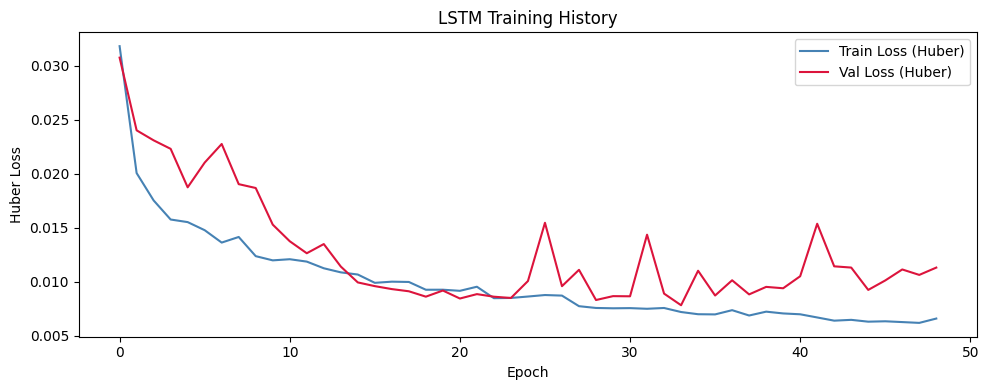

In [23]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train Loss (Huber)', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss (Huber)', color='crimson')
ax.set_title('LSTM Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_training_history_anand_vihar.png', dpi=150)
plt.show()

## 7. Forecast & Evaluation

In [24]:
# Direct (one-step-ahead for each test window using actual data)
pred_scaled = model.predict(X_test, verbose=0)
pred_aqi = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_aqi = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(actual_aqi, pred_aqi))
mae  = mean_absolute_error(actual_aqi, pred_aqi)
mape = np.mean(np.abs((actual_aqi - pred_aqi) / actual_aqi)) * 100

print(f'LSTM Performance on Test Set:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')

LSTM Performance on Test Set:
  RMSE : 61.22
  MAE  : 49.53
  MAPE : 35.68%


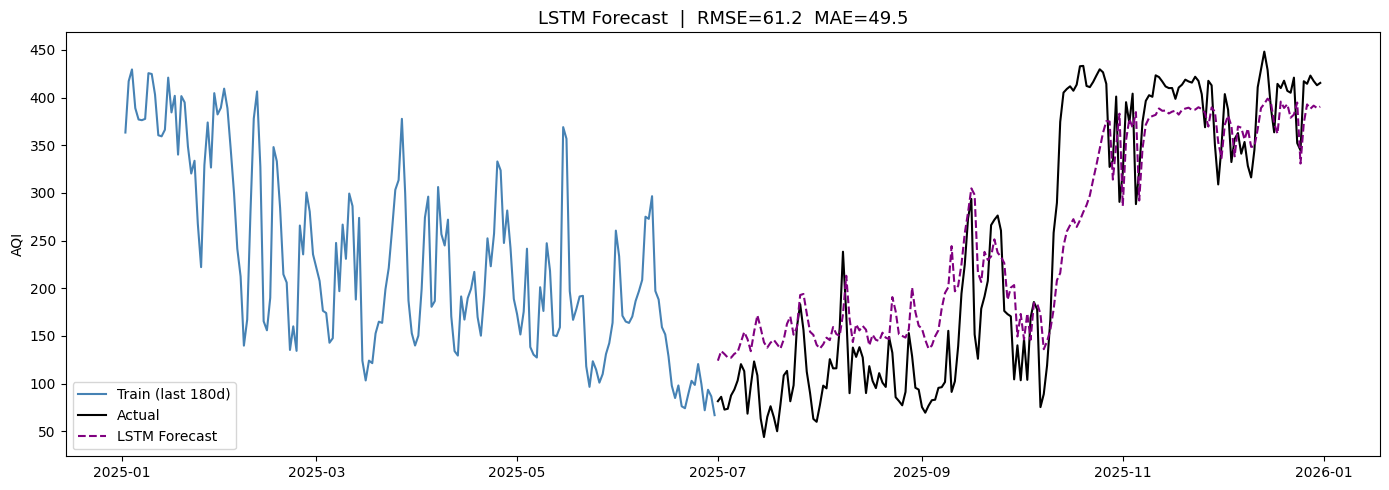

In [25]:
# Get last 180 days of training for context
train_aqi_orig = scaler_y.inverse_transform(y_train[-180:].reshape(-1, 1)).flatten()
train_dates    = dates[split_idx-180:split_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_dates, train_aqi_orig, label='Train (last 180d)', color='steelblue')
ax.plot(dates_test, actual_aqi, label='Actual', color='black', linewidth=1.5)
ax.plot(dates_test, pred_aqi, label='LSTM Forecast', color='purple', linestyle='--')
ax.set_title(f'LSTM Forecast  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_forecast_anand_vihar.png', dpi=150)
plt.show()

## 8. Residual Analysis

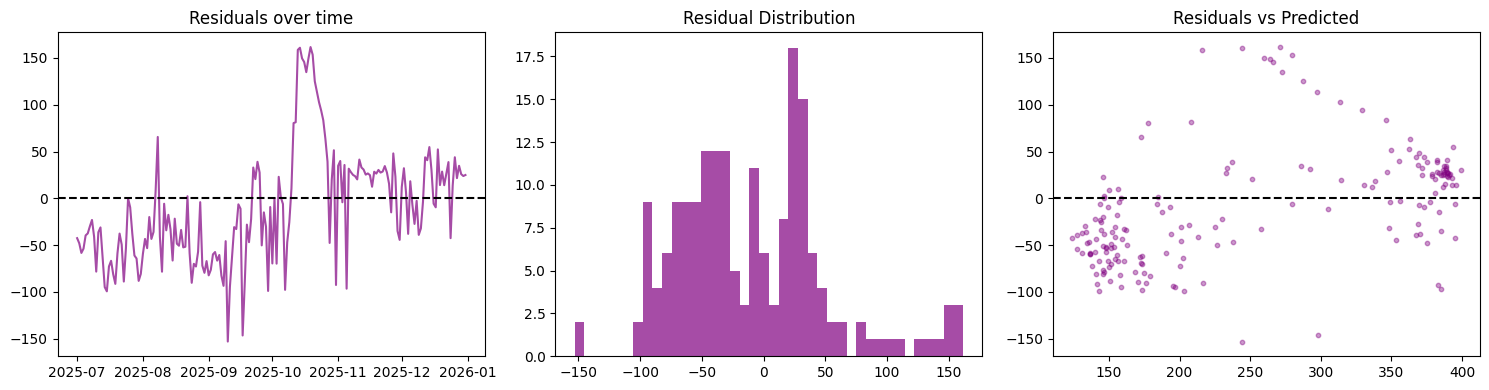

In [26]:
residuals = actual_aqi - pred_aqi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(dates_test, residuals, color='purple', alpha=0.7)
axes[0].axhline(0, linestyle='--', color='black')
axes[0].set_title('Residuals over time')
axes[1].hist(residuals, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Residual Distribution')
axes[2].scatter(pred_aqi, residuals, alpha=0.4, color='purple', s=10)
axes[2].axhline(0, linestyle='--', color='black')
axes[2].set_title('Residuals vs Predicted')
plt.tight_layout()
plt.savefig('lstm_residuals_anand_vihar.png', dpi=150)
plt.show()

In [28]:
# Save model weights
model.save('lstm_anand_vihar_aqi_model.keras')
print('Model saved to lstm_anand_vihar_aqi_model.keras')

Model saved to lstm_anand_vihar_aqi_model.keras
